# Decision Tree（現代化版本）

這一段把原本的 Decision Tree 內容整體更新成較符合現在實務與面試習慣的寫法。

## 更新重點
1. 使用 `stratify=y`，讓 train/test 的類別比例更穩定  
2. 不只看一次 `score()`，也補上 `classification_report` 與交叉驗證  
3. 補上控制樹複雜度的重要參數：`min_samples_split`、`min_samples_leaf`、`ccp_alpha`  
4. 視覺化以 `plot_tree()` 為主，`graphviz` 當作可選補充  
5. 特徵重要性除了 `feature_importances_`，也加入 `permutation_importance` 當對照  

> 小提醒：Decision Tree 通常**不需要特徵標準化**，因為它不是靠距離在切資料，而是靠條件判斷一路往下分支。

## 載入套件與資料

這裡先載入 iris 資料集。前半段先用 **4 個特徵做完整分類**，後半段再另外挑 **2 個特徵** 來畫 decision boundary。

In [32]:
%matplotlib inline

# 基本套件
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import os, sys

# 資料與模型
from sklearn import datasets, tree
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz

# 資料切分與驗證
from sklearn.model_selection import (
    train_test_split,     # 切訓練/測試資料
    StratifiedKFold,      # 保持類別比例的交叉驗證切法（主要在處理資料切分）
    cross_validate,       # 多指標交叉驗證（會用 StratifiedKFold 切分的資料進行驗證，評估模型，cross_val_score 僅能知道單一分數）
    GridSearchCV          # 參數搜尋（在多組參數上重複進行 cross_validate，調參時可取代 cross_validate，但調參完可以再回頭用 cv 評估） 
)
# 可以以這樣的順序進行驗證
# cross_val_score -> cross_validate -> GridSearchCV -> cross_validate(best_model, ...)

# 模型評估
from sklearn.metrics import (
    accuracy_score,          # 基本準確率
    classification_report,   # precision / recall / f1
    confusion_matrix,        # 混淆矩陣
    ConfusionMatrixDisplay   # 混淆矩陣視覺化
)

# 特徵重要性（較進階）
from sklearn.inspection import permutation_importance

# 視覺化（進階）
from graphviz import Source  # # 匯出決策樹為圖檔（非必要）

# 自訂工具
# 注意：這裡是將當前資料夾加入 Python 路徑，方便 import 自寫模組
sys.path.append(os.path.abspath('./'))  # for import common.utility
from utility import (
    plot_decision_regions,    # 畫 decision boundary（僅適用低維） 
    testcase_report           # 自訂測試結果整理
)

In [12]:
iris = datasets.load_iris()

iris_data = pd.DataFrame(iris["data"], columns=iris["feature_names"])
iris_data["target"] = iris["target"]

target_name_map = dict(enumerate(iris["target_names"])) # 供後續繪圖的 class 對照使用

print("feature_names:", iris["feature_names"])
print("target_names:", iris["target_names"])
print()
display(iris_data.head())

feature_names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target_names: ['setosa' 'versicolor' 'virginica']



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 建立訓練集 / 測試集

這裡加上 `stratify=iris_data["target"]`。  
原因是 iris 雖然很乾淨，但分類問題在切資料時，仍建議讓訓練集與測試集保有相近的類別比例。

In [13]:
X = iris_data.drop(columns="target")
y = iris_data["target"]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train_all shape:", X_train_all.shape)
print("X_test_all shape:", X_test_all.shape)
print()
print("train class ratio:")
print(y_train_all.value_counts(normalize=True).sort_index()) 
print()
print("test class ratio:")
print(y_test_all.value_counts(normalize=True).sort_index())

X_train_all shape: (105, 4)
X_test_all shape: (45, 4)

train class ratio:
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

test class ratio:
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


## Decision Tree 常用參數（新版教學重點）

### 1. `criterion`
分裂品質的衡量方式。常見有：
- `gini`：分類是否正確（預設參數，一般使用這個即可，計算快速）
- `entropy`：分類是否正確
- `log_loss`：預測的機率有多準（會懲罰「高信心的錯誤」），讓 decision tree 的思維跟其他機率導向的模型一致，不只在意預測是否正確，也在意預測機率是否合理（如：sigmoid / logistic regression / cross entropy / Neural Network / XGBoost / LightGBM）

### 2. `max_depth`
限制樹最深可以長到幾層。太深容易 overfitting。

### 3. `min_samples_split`
一個節點至少要有多少樣本，才允許再往下切。（切之前）

### 4. `min_samples_leaf`
葉節點至少保留多少樣本。這個參數常用來避免葉子太碎。（切之後）

### 5. `ccp_alpha`
Cost-Complexity Pruning（成本複雜度剪枝）的強度。  
越大代表剪得越兇，模型會更保守。  
透過在模型錯誤之外加入「複雜度懲罰」，剪除貢獻不足的分支。  
在「準確度」與「模型簡單性」之間做平衡。  

ccp_alpha 越大 → 剪枝越多 → 模型越簡單  
ccp_alpha 越小 → 保留更多分支 → 模型越複雜  

可理解為：  
一個分裂只有在「帶來的改善大於懲罰」時才會被保留。

> 實務上通常不是只調 `max_depth`，而是會一起看 `min_samples_split`、`min_samples_leaf`、`ccp_alpha`。

## 先建立一棵 baseline tree

這裡示範一個比較像現代入門版本的設定：
- `criterion="log_loss"`：新版也支援，和 `entropy` 一樣走資訊增益概念
- `max_depth=4`：先限制樹深
- `min_samples_split=4`
- `min_samples_leaf=2`
- `ccp_alpha=0.0`：先不額外剪枝

In [14]:
dt_baseline = DecisionTreeClassifier(
    criterion="log_loss",
    max_depth=4,
    min_samples_split=4,
    min_samples_leaf=2,
    ccp_alpha=0.0,
    random_state=42
)

dt_baseline.fit(X_train_all, y_train_all)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'log_loss'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

## 補充：有關何時使用 test data set？

1. data cleaning：僅做不涉及資料洩漏的基本整理
    - 改欄位名稱
    - 修正明顯錯字
    - 移除明顯重複列
    - 型別轉換

2. train_test_split：先切分資料，test set 鎖起來

3. 建立 baseline Pipeline（只用 train）
    - 補缺失值
    - (必要時）標準化
    - encoding
    - baseline model

4. baseline model 評估（只用 train）  
    → 使用 train 資料進行 cross_validate  
    → 初步了解模型是否可行、是否有 overfitting  

5. 模型理解（只用 train）（validation / CV）：作為理解模型與特徵的依據  
    → feature_importances_  
    → permutation_importance（建議使用 validation / CV）  

6. 特徵工程 / 特徵篩選（只用 train）：建議整合進 Pipeline（避免後續 leakage）

7. Pipeline + GridSearchCV（只用 train）：
    → 同時搜尋：  
        - 特徵處理流程  
        - 特徵選擇  
        - 模型參數  

8. 取得 best_estimator_

9. 最終 test 評估（只做一次）

以上的 Pipeline 基本上是「骨架相同」的  
通常到特徵篩選階段，可能會有另一條新的 Pipeline 補入特徵篩選（selector） 

predict(X_test) 本身不會造成 data leakage。  
但如果根據 test set 的結果來調整模型（例如修改參數、選擇模型），  
就會使 test data 的資訊間接影響模型，造成 data leakage。  

關鍵不是「是否使用 test」，而是「是否用 test 做決策」。

## 基本評估：不要只看 `score()`

`score()` 對分類器來說預設就是 accuracy。 
$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$  

但在實務上，通常至少會再補：
- `classification_report`
    - precision: TP / (TP + FP) 被**預測**為此類別中，有多少是真的（預測正例 / 所有被預測為該類）  
      例如：人臉辨識（避免誤抓）
    - recall: TP / (TP + FN) **實際**屬於此類別中，有多少被成功預測出來（預測正例 / 所有真實該類）  
      例如：疾病篩檢、自動駕駛車輛行人辨識（避免漏抓）
    - f1-score: 2 * (precision * recall) / (precision + recall)  
      平衡指標，同時考量誤判與漏判（使用 Harmonic Mean 調和平均數的概念，Precision 和 Recall 要同時好，才會高分）
    - support: 該類別在**真實**資料中的樣本數量
    - accuracy: (TP + TN) / 全部資料 整體預測正確的比例（但在類別不平衡時可能具有誤導性）
    - marco avg: 對每類的 precision / recall / f1-score 做「不加權平均」（不考慮樣本數量）
    - weighted avg: 根據各類的 support 加權平均 precision / recall / f1-score（樣本多影響大）

$$
Precision = \frac{TP}{TP + FP}
$$

$$
Recall = \frac{TP}{TP + FN}
$$

$$
F1\ Score = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}
$$

- `confusion_matrix`

這樣比較能看出各類別預測得好不好。

In [15]:
y_pred_train = dt_baseline.predict(X_train_all)
# y_pred_test = dt_baseline.predict(X_test_all)

print("train accuracy:", accuracy_score(y_train_all, y_pred_train))
# print("test accuracy :", accuracy_score(y_test_all, y_pred_test))

train accuracy: 0.9809523809523809


In [16]:
print("=== Training classification report ===")
print(classification_report(y_train_all, y_pred_train, target_names=iris["target_names"]))

# print("=== Test classification report ===")
# print(classification_report(y_test_all, y_pred_test, target_names=iris["target_names"]))

=== Training classification report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        35
  versicolor       0.95      1.00      0.97        35
   virginica       1.00      0.94      0.97        35

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105



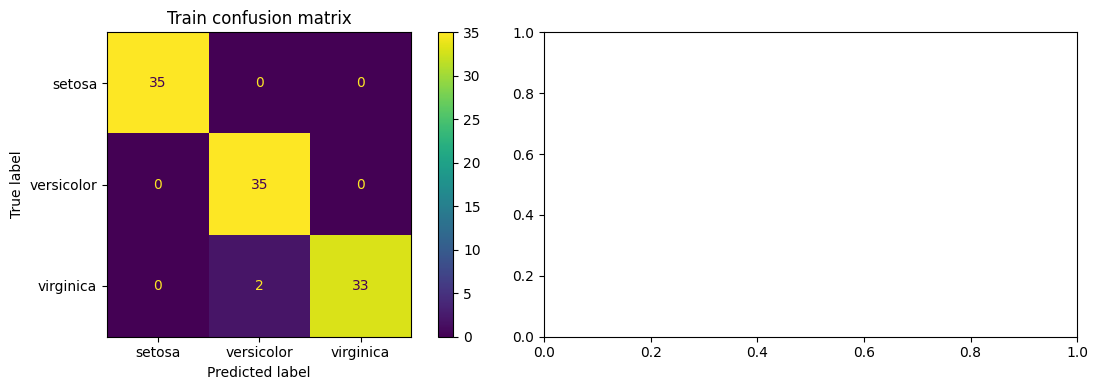

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_train_all, y_pred_train,
    display_labels=iris["target_names"],
    ax=axes[0]
)
axes[0].set_title("Train confusion matrix")

# ConfusionMatrixDisplay.from_predictions(
#     y_test_all, y_pred_test,
#     display_labels=iris["target_names"],
#     ax=axes[1]
# )
# axes[1].set_title("Test confusion matrix")

plt.tight_layout()
plt.show()

## 1.8.交叉驗證：比單次切分更穩

Decision Tree 對資料切分方式比較敏感。  
所以除了單次 train/test split，常會再補交叉驗證，看看模型表現是否穩定。

`scoring 選擇：`
- accuracy：適用於類別平衡
- f1-score：適用於類別不平衡
- precision / recall：當某類別特別重要時使用

實務建議：
通常同時觀察 accuracy 與 f1_macro，以避免被單一指標誤導。

在 cross-validation 中：

mean score：
代表模型平均表現

std score：
代表模型在不同資料切分下的`穩定性`

判讀原則：
- mean 高 + std 小 → 理想模型
- mean 高 + std 大 → 不穩，可能 overfitting
- mean 普通 + std 小 → 穩但可再優化

實務上：
`當模型表現相近時，優先選擇 std 較小的模型`

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# shuffle 的目的，是在分層抽樣前先打亂資料順序，
# 避免因資料原始排序造成每一折的特徵分布偏差。

cv_result = cross_validate(
    dt_baseline,
    X_train_all,
    y_train_all,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=True
)

cv_summary = pd.DataFrame({
    "metric": ["train_accuracy", "valid_accuracy", "train_f1_macro", "valid_f1_macro"],
    "mean": [
        cv_result["train_accuracy"].mean(),
        cv_result["test_accuracy"].mean(),
        cv_result["train_f1_macro"].mean(),
        cv_result["test_f1_macro"].mean()
    ],
    "std": [
        cv_result["train_accuracy"].std(),
        cv_result["test_accuracy"].std(),
        cv_result["train_f1_macro"].std(),
        cv_result["test_f1_macro"].std()
    ]
})

display(cv_summary)

,metric,mean,std
0,train_accuracy,0.983333,0.009524
1,valid_accuracy,0.942857,0.035635
2,train_f1_macro,0.983310,0.009563
3,valid_f1_macro,0.942363,0.036039


## 視覺化決策樹：優先用 `plot_tree()`

這是現在在 notebook 裡最方便的做法。  
好處是不用先輸出成檔案，直接在 notebook 看就行。

- value：各類別的樣本數量
- class：該節點中樣本數最多的類別（majority class）

root 節點的 class：
- 代表整個訓練資料的多數類別
- 可視為 baseline 預測（若模型不進行任何分裂）

用途：
1. 判斷資料是否不平衡
2. 理解 baseline accuracy
3. 作為後續分裂效果的對照基準

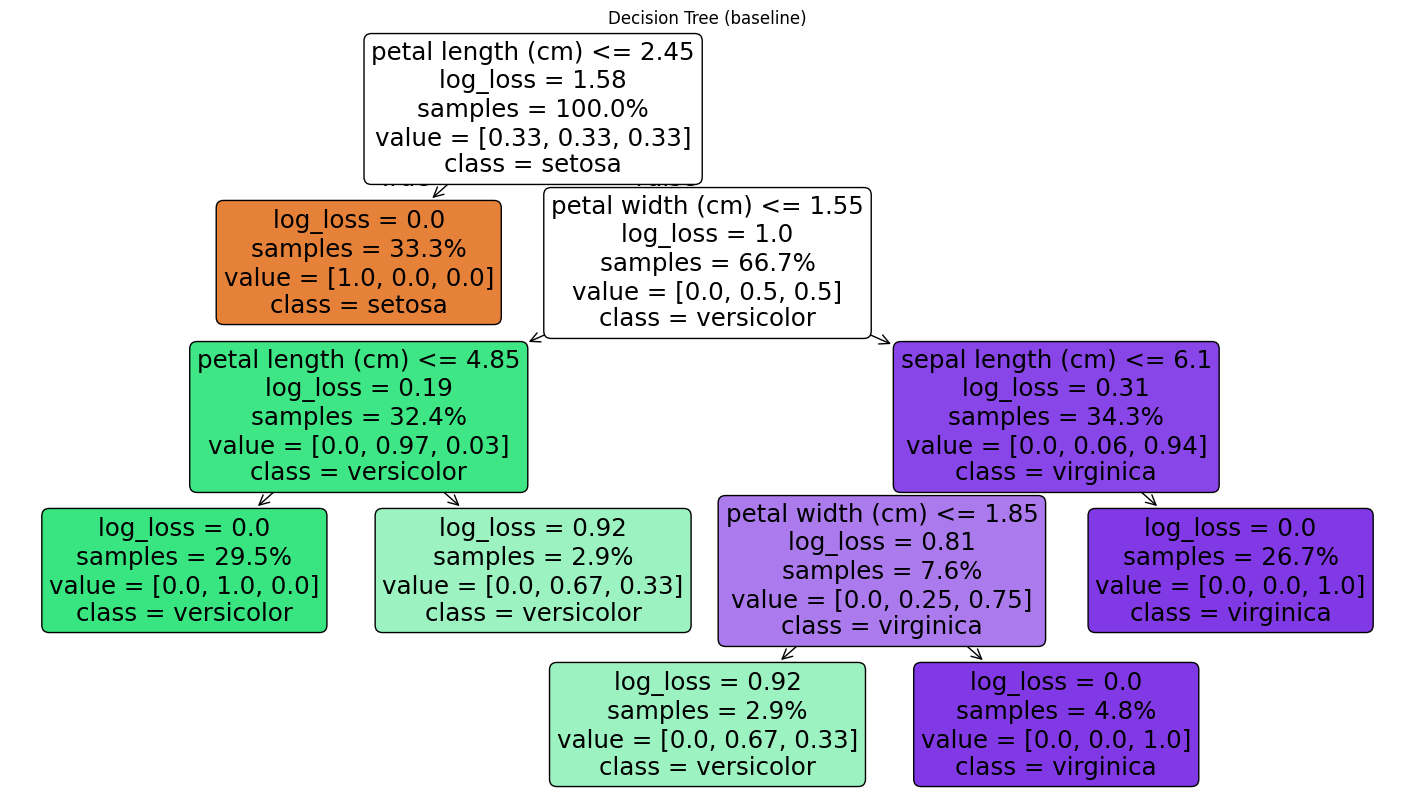

In [26]:
plt.figure(figsize=(18, 10))
plot_tree(
    dt_baseline,
    feature_names=X_train_all.columns,
    class_names=[target_name_map[c] for c in dt_baseline.classes_],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2
)
plt.title("Decision Tree (baseline)")
plt.show()

## 如果想輸出成檔案，再用 `graphviz`

`graphviz` 適合在樹比較大時輸出成 PDF 檔檢視。  
這裡保留為可選做法，不再以 `pydotplus` 為主。

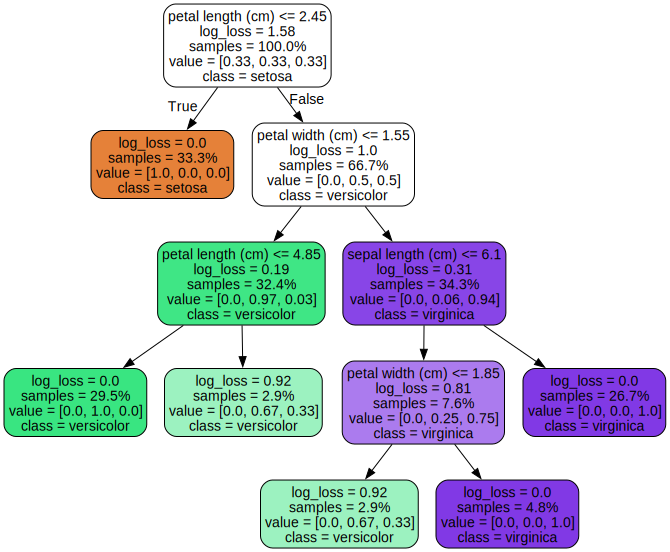

In [27]:
dot_data = export_graphviz(
    dt_baseline,
    out_file=None,
    feature_names=X_train_all.columns,
    class_names=[target_name_map[c] for c in dt_baseline.classes_],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2
)

graph = Source(dot_data)
graph

In [28]:
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

graph.render(
    filename="decision_tree_baseline",
    directory=str(output_dir),
    format="pdf",
    cleanup=True
)

print("已輸出到:", output_dir / "decision_tree_baseline.pdf")

已輸出到: output/decision_tree_baseline.pdf


## 特徵重要性：先看模型內建，再用 permutation importance 對照
### `feature_importances_`

**（這個特徵帶來的分類改善總量）/（所有特徵帶來的分類改善總量）**  
**這個特徵幫助模型做對決策的比例（衡量特徵在訓練過程中的重要程度）**   

這是樹模型內建的 impurity-based importance，速度快、很方便。

#### 缺點
- 偏愛連續特徵（如數值資料）
- 受資料切分方式影響
- 僅為模型內部觀點

#### 但它不是絕對真理
遇到：
- 高基數特徵
- 彼此高度相關的特徵

時，解讀要保守一點。  
所以比較好的習慣是：**再用 permutation importance 做一次對照**。

### `permutation importance`

**（原本模型表現 - 打亂後模型表現）/ 原本模型表現**  
**衡量特徵對最終預測結果的影響程度**

外部實驗驗證，將某特徵打亂，看模型變化
但若有高度相關的複數特徵，僅打亂其中之一會導致結果混淆

1. 先看 feature_importances_
   → 快速理解模型
2. 再看 permutation_importance
   → 驗證重要性
3. 如果兩者差很多
   → 懷疑：
      - 特徵相關性
      - 資料問題
      - 模型不穩

In [29]:
mdi_importance = pd.Series(
    dt_baseline.feature_importances_,
    index=X_train_all.columns,
    name="mdi_importance"
).sort_values(ascending=False)

display(mdi_importance.to_frame())

,mdi_importance
petal length (cm),0.622547
petal width (cm),0.348534
sepal length (cm),0.028919
sepal width (cm),0.000000


In [30]:
perm_result = permutation_importance(
    dt_baseline,
    X_test_all,
    y_test_all,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X_test_all.columns,
    name="permutation_importance"
).sort_values(ascending=False)

display(perm_importance.to_frame())

,permutation_importance
petal length (cm),0.387407
petal width (cm),0.150370
sepal width (cm),0.000000
sepal length (cm),-0.001481


## feature_importances_ vs permutation_importance 判讀

### 核心原則
- 兩者一致 → 特徵重要性可信度高  
- 兩者不一致 → 需要進一步檢查（可能有問題或特殊情況）

留意 permutation_importance 中的負值

---
### 四種情況

1. #### `兩者都高（重要特徵）`

feature_importances_ ↑  
permutation_importance ↑

→ 結論：  
這個特徵在訓練過程中常被使用，且對最終預測影響很大  
→ 真正重要的關鍵特徵，可放心使用  


2. #### `tree 高，但 permutation 低（被高估）`

feature_importances_ ↑  
permutation_importance ↓

→ 可能原因：  
- 特徵之間高度相關（可互相替代）  
- 樹模型偏好某些特徵（如連續特徵）  

→ 結論：  
模型「以為重要」，但實際影響有限  
→ 需檢查特徵相關性（例如 correlation）


3. #### `tree 低，但 permutation 高（被低估）`

feature_importances_ ↓  
permutation_importance ↑  

→ 可能原因：  
- 特徵沒有頻繁被用來分裂  
- 但一旦改變，對預測影響很大  

→ 結論：  
這是被模型低估的關鍵特徵  
→ 值得特別關注與保留  


4. #### `兩者都低（可刪除）`

feature_importances_ ↓  
permutation_importance ↓  

→ 結論：  
這個特徵對模型幾乎沒有幫助  
→ 可以考慮移除以簡化模型

---

### 補充觀念

- feature_importances_
  → 衡量「訓練過程中」的貢獻（模型內部觀點）

- permutation_importance
  → 衡量「預測結果」的影響（模型外部驗證）

- 若兩者差異很大：  
  → 優先相信 permutation_importance  
  → 並檢查：
    - 特徵相關性
    - 資料品質
    - 模型是否過擬合

In [34]:
importance_compare = pd.concat([mdi_importance, perm_importance], axis=1)
importance_compare

,mdi_importance,permutation_importance
petal length (cm),0.622547,0.387407
petal width (cm),0.348534,0.150370
sepal length (cm),0.028919,-0.001481
sepal width (cm),0.000000,0.000000


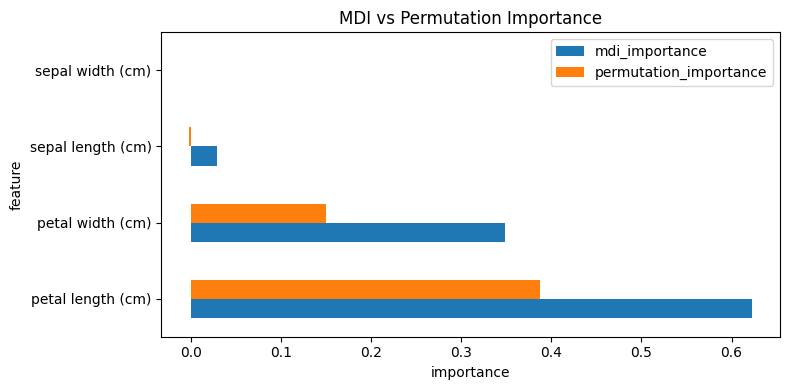

In [35]:
importance_compare.plot.barh(figsize=(8, 4))
plt.title("MDI vs Permutation Importance")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
plt.show()

## 補充：ccp_alpha 參數搜尋示範

**`實務建議以 GridSearchCV 做完整參數搜尋及調整`**

```python
path = dt_baseline.cost_complexity_pruning_path(X_train_all, y_train_all)
ccp_alphas = path.ccp_alphas

train_scores = []
test_scores = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha)
    model.fit(X_train_all, y_train_all)
    
    train_scores.append(model.score(X_train_all, y_train_all))
    test_scores.append(model.score(X_test_all, y_test_all))

plt.plot(ccp_alphas, train_scores, label="train")
plt.plot(ccp_alphas, test_scores, label="test")
plt.xlabel("ccp_alpha")
plt.ylabel("score")
plt.legend()
```

## GridSearchCV 參數搜尋示範

現在更常見的做法不是只手動改一個 `max_depth`，而是讓 `GridSearchCV` 幫忙比較幾組合理的組合。  
這裡先示範小範圍搜尋，概念比參數海更重要，不然電腦會開始懷疑人生。

GridSearchCV 並不限於使用 F1-score。

其最佳分數（best_score_）取決於 scoring 參數：

- 若設定 scoring="f1_macro"，則 best_score_ 為 F1 分數
- 若未設定 scoring，分類問題預設為 accuracy

實務建議：
- 不平衡資料：使用 f1_macro
- 平衡資料：可使用 accuracy
- 需要多指標時，可使用 scoring=dict 並設定 refit 指定最終依據指標

進階
```python
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1_macro"
    },
    refit="f1",
    cv=cv
)
grid.cv_results_
```

In [36]:
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 3],
    "ccp_alpha": [0.0, 0.001, 0.01]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42), # 若有用 pipeline，這邊可以改放 pipeline
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train_all, y_train_all)

print("best params:", grid.best_params_)
print("best cv f1_macro:", grid.best_score_)

best params: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
best cv f1_macro: 0.9519352869352868


## 套用最佳參數組合，再次進行模型評估

In [37]:
dt_best = grid.best_estimator_

y_pred_best_test = dt_best.predict(X_test_all)

print("best model test accuracy:", accuracy_score(y_test_all, y_pred_best_test))
print(classification_report(y_test_all, y_pred_best_test, target_names=iris["target_names"]))

best model test accuracy: 0.9777777777777777
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## 和 `entropy` 版本對照一下

很多教材還是會用 `criterion="entropy"` 來示範。  
這裡保留一棵 `entropy` 版本，方便你直接比較，不然 `log_loss` 看起來像是突然冒出來的親戚。

In [38]:
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

dt_entropy.fit(X_train_all, y_train_all)

print("entropy train accuracy:", dt_entropy.score(X_train_all, y_train_all))
print("entropy test accuracy :", dt_entropy.score(X_test_all, y_test_all))

entropy train accuracy: 0.9809523809523809
entropy test accuracy : 0.8444444444444444


## 補充：如果你習慣用原本的 `testcase_report`

這一段只是延續你原本 notebook 的風格。  
如果 `utility.py` 有提供 `testcase_report()`，可以繼續拿來快速查看訓練集與測試集結果。

In [39]:
report = testcase_report(iris_data, dt_best, X_train_all, X_train_all, y_train_all)
report[0]

accuracy: 0.9809523809523809
error_index : [19 82]
miss classification : [2 1]
number of errors :2/105
error data index: Index([70, 129], dtype='int64')


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,pred
70,5.9,3.2,4.8,1.8,1,2
129,7.2,3.0,5.8,1.6,2,1


In [40]:
report = testcase_report(iris_data, dt_best, X_test_all, X_test_all, y_test_all)
report[0]

accuracy: 0.9777777777777777
error_index : [39]
miss classification : [2]
number of errors :1/45
error data index: Index([77], dtype='int64')


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,pred
77,6.7,3.0,5.0,1.7,1,2


## 只挑 2 個特徵來畫 decision boundary

這裡要特別注意：

- **畫 decision boundary 通常只適合 2 個特徵**
- 真正訓練模型時不一定只能用 2 個特徵
- 這一步主要是為了幫助理解模型怎麼切分平面

In [41]:
feature_cols_2d = ["petal width (cm)", "petal length (cm)"]

X_2d = iris_data[feature_cols_2d]
y_2d = iris_data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.3,
    random_state=42,
    stratify=y_2d
)

clf_3 = DecisionTreeClassifier(
    criterion="log_loss",
    max_depth=3,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

clf_3.fit(X_train, y_train)

print("2D train accuracy:", clf_3.score(X_train, y_train))
print("2D test accuracy :", clf_3.score(X_test, y_test))

2D train accuracy: 0.9714285714285714
2D test accuracy : 0.8888888888888888


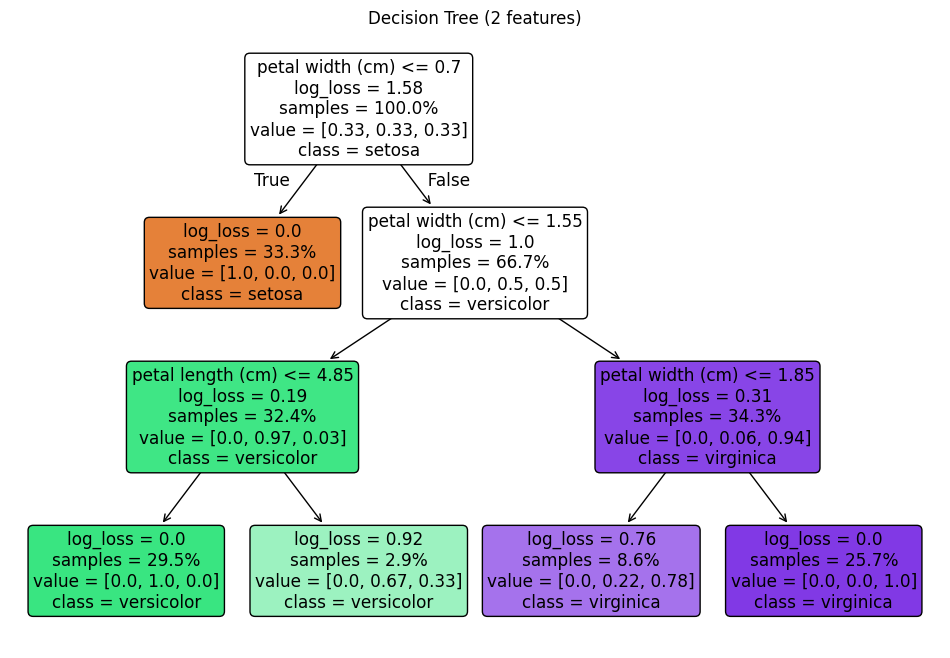

In [42]:
plt.figure(figsize=(12, 8))
plot_tree(
    clf_3,
    feature_names=feature_cols_2d,
    class_names=[target_name_map[c] for c in clf_3.classes_],
    filled=True, 
    rounded=True, 
    proportion=True,
    precision=2
)
plt.title("Decision Tree (2 features)")
plt.show()

## 視覺化決策邊界

Decision boundary = 特徵 + 模型限制 + 分裂策略

這張圖的重點不是「真實世界永遠只會有兩個特徵」，  
而是幫助你觀察 Decision Tree 如何用一條一條水平 / 垂直切線把空間分開。

/Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


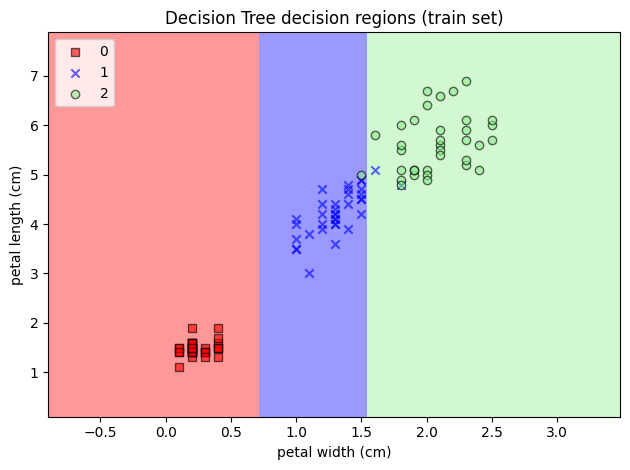

In [43]:
plot_decision_regions(X_train.values, y_train, classifier=clf_3)
plt.title("Decision Tree decision regions (train set)")
plt.xlabel(feature_cols_2d[0])
plt.ylabel(feature_cols_2d[1])
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

/Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


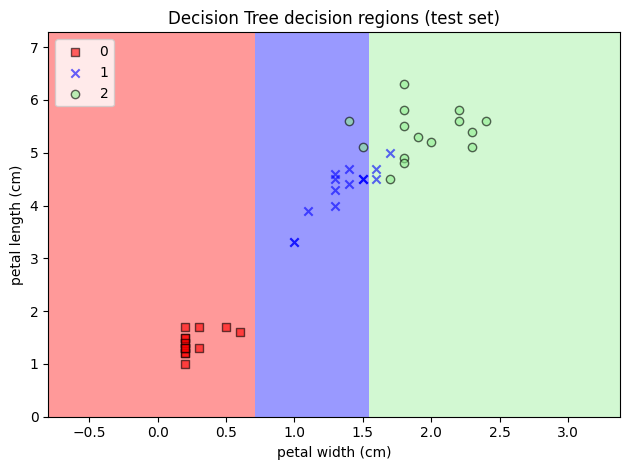

In [24]:
plot_decision_regions(X_test.values, y_test, classifier=clf_3)
plt.title("Decision Tree decision regions (test set)")
plt.xlabel(feature_cols_2d[0])
plt.ylabel(feature_cols_2d[1])
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Random Forest（現代化版本）

Random Forest 可以理解成：**不是只種一棵容易暴衝的樹，而是種很多棵樹，再讓它們投票。**

相較於單棵 Decision Tree，Random Forest 通常：
- 泛化能力更穩
- 比較不容易 overfitting
- 幾乎不需要做特徵標準化
- 但可解釋性會比單棵樹弱一些


## 建立 Random Forest 的 baseline 模型

這裡先用一個比較符合現代實務感的 baseline：
- `n_estimators=300`：樹的數量不要太少，10 棵通常偏教學示範
- `criterion="log_loss"`：新版 sklearn 支援，可一起認識
- `max_depth` / `min_samples_split` / `min_samples_leaf`：一起控制樹的複雜度
- `class_weight="balanced"`：資料不平衡時很常見；Iris 很平衡，但這裡先示範這個觀念
- `n_jobs=-1`：盡量使用可用 CPU 核心

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=300,        # 實務可以考慮 100 ~ 500
    criterion="log_loss",    # 基本上可以用預設的 gini 就好
    max_depth=4,
    min_samples_split=4,
    min_samples_leaf=2,      # 穩定性的關鍵，也可以考慮 5 ~ 10
    max_features="sqrt",     # 核心參數，每次分裂時，隨機抽一部分特徵來挑
    bootstrap=True,          # 核心參數，每棵樹都用「不同版本的資料」訓練
    oob_score=True,          # out-of-bag score：內部評估，用每棵樹「沒抽到的那些資料」做內部驗證
    class_weight="balanced", # 會根據類別出現頻率，自動給少數類比較高權重
    random_state=42,
    n_jobs=-1                #用電腦所有 CPU 核心一起跑
)

rf_baseline.fit(X_train_all, y_train_all)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'log_loss'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

## 參數說明補充

Random Forest 常見的幾個現代重點參數：

- `n_estimators`：森林裡有幾棵樹。太少時結果容易不穩。
- `max_features`：每次分裂時能看到多少特徵。分類問題常見預設概念是 `sqrt`。
- `bootstrap=True`：每棵樹都從訓練資料中重抽樣，增加樹與樹之間的差異。
- `oob_score=True`：利用沒被抽到的資料做內部驗證。
- `max_depth / min_samples_split / min_samples_leaf`：控制每棵樹不要長得太誇張。

每棵樹都會 bootstrap 抽「N筆資料」（N=原始資料大小），
而整個森林會有 n_estimators 棵樹。

`min_samples_leaf`：控制單棵樹的「細膩程度」
- Decision Tree：要大一點（避免 overfit）  
- Random Forest：可以小一點（因為會平均）

## 基本評估：除了 accuracy，也要看 precision / recall / f1

Random Forest 雖然常常分數不錯，但不要因為分數漂亮就直接歡呼。
先看：
- 訓練集與測試集是否差太多
- classification report
- confusion matrix
- OOB score 是否和測試集表現大致一致


In [46]:
rf_pred_train = rf_baseline.predict(X_train_all)
rf_pred_test = rf_baseline.predict(X_test_all)

print("Random Forest train accuracy:", rf_baseline.score(X_train_all, y_train_all))
print("Random Forest test accuracy:", rf_baseline.score(X_test_all, y_test_all))
print("Random Forest OOB score:", rf_baseline.oob_score_)


Random Forest train accuracy: 0.9714285714285714
Random Forest test accuracy: 0.9111111111111111
Random Forest OOB score: 0.9523809523809523


In [47]:
print("=== Random Forest / Training classification report ===")
print(classification_report(y_train_all, rf_pred_train, target_names=iris["target_names"]))

print("=== Random Forest / Test classification report ===")
print(classification_report(y_test_all, rf_pred_test, target_names=iris["target_names"]))


=== Random Forest / Training classification report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        35
  versicolor       0.97      0.94      0.96        35
   virginica       0.94      0.97      0.96        35

    accuracy                           0.97       105
   macro avg       0.97      0.97      0.97       105
weighted avg       0.97      0.97      0.97       105

=== Random Forest / Test classification report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



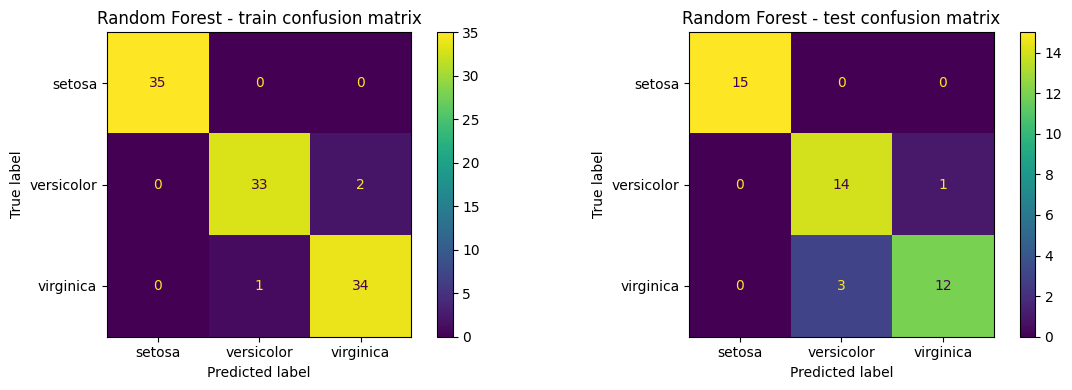

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_train_all, rf_pred_train, ax=axes[0], display_labels=iris["target_names"])
axes[0].set_title("Random Forest - train confusion matrix")

ConfusionMatrixDisplay.from_predictions(y_test_all, rf_pred_test, ax=axes[1], display_labels=iris["target_names"])
axes[1].set_title("Random Forest - test confusion matrix")
plt.tight_layout()


## 交叉驗證：確認模型不是剛好運氣好

如果只做一次 train/test split，有時會被切分運氣影響。
所以這裡也用 `StratifiedKFold` + `cross_validate` 來看更穩定的表現。


In [49]:
rf_cv = cross_validate(
    rf_baseline,
    X_train_all,
    y_train_all,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=True,
    n_jobs=-1
)

pd.DataFrame(rf_cv).agg(["mean", "std"]).T


,mean,std
fit_time,0.286759,0.005289
score_time,0.036774,0.007445
test_accuracy,0.961905,0.039841
train_accuracy,0.978571,0.009960
test_f1_macro,0.961807,0.039870
train_f1_macro,0.978568,0.009963


## 特徵重要性：一樣要小心，不要把模型講的話當神諭

先看內建的 impurity-based importance（MDI），再用 permutation importance 做對照。
若兩者差很多，就要提高警覺：
- 特徵間可能高度相關
- 資料量可能不夠
- 模型的重要性排序可能不穩


In [50]:
rf_mdi_importance = pd.Series(
    rf_baseline.feature_importances_,
    index=X_train_all.columns,
    name="RF_MDI_importance"
).sort_values(ascending=False)

rf_mdi_importance


petal length (cm)    0.434669
petal width (cm)     0.428323
sepal length (cm)    0.118634
sepal width (cm)     0.018374
Name: RF_MDI_importance, dtype: float64

In [51]:
rf_perm_result = permutation_importance(
    rf_baseline,
    X_test_all,
    y_test_all,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

rf_perm_importance = pd.Series(
    rf_perm_result.importances_mean,
    index=X_test_all.columns,
    name="RF_permutation_importance"
).sort_values(ascending=False)

rf_perm_importance


petal length (cm)    0.196296
petal width (cm)     0.162222
sepal length (cm)    0.008889
sepal width (cm)     0.000000
Name: RF_permutation_importance, dtype: float64

In [52]:
rf_importance_compare = pd.concat([rf_mdi_importance, rf_perm_importance], axis=1)
rf_importance_compare


,RF_MDI_importance,RF_permutation_importance
petal length (cm),0.434669,0.196296
petal width (cm),0.428323,0.162222
sepal length (cm),0.118634,0.008889
sepal width (cm),0.018374,0.000000


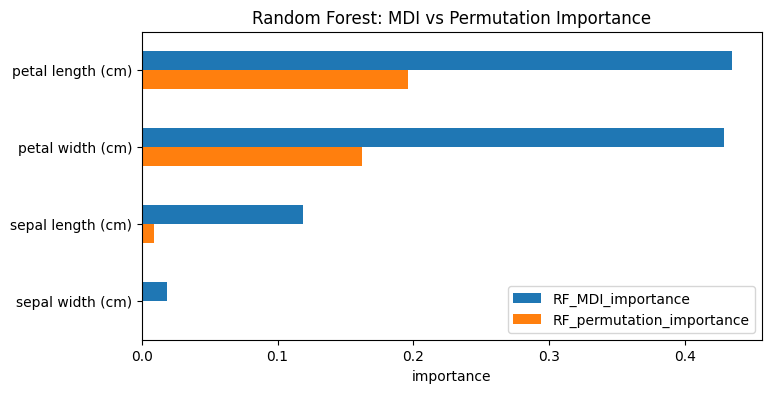

In [55]:
rf_importance_compare.plot.barh(figsize=(8, 4))
plt.title("Random Forest: MDI vs Permutation Importance")
plt.xlabel("importance")
plt.gca().invert_yaxis()
plt.show()

## 看其中一棵樹長什麼樣子

Random Forest 本身不是一棵樹，而是一整片森林。
如果你想理解模型在做什麼，可以先抽其中一棵出來看，但要記得：
**它只代表森林中的其中一名成員，不代表全體。**


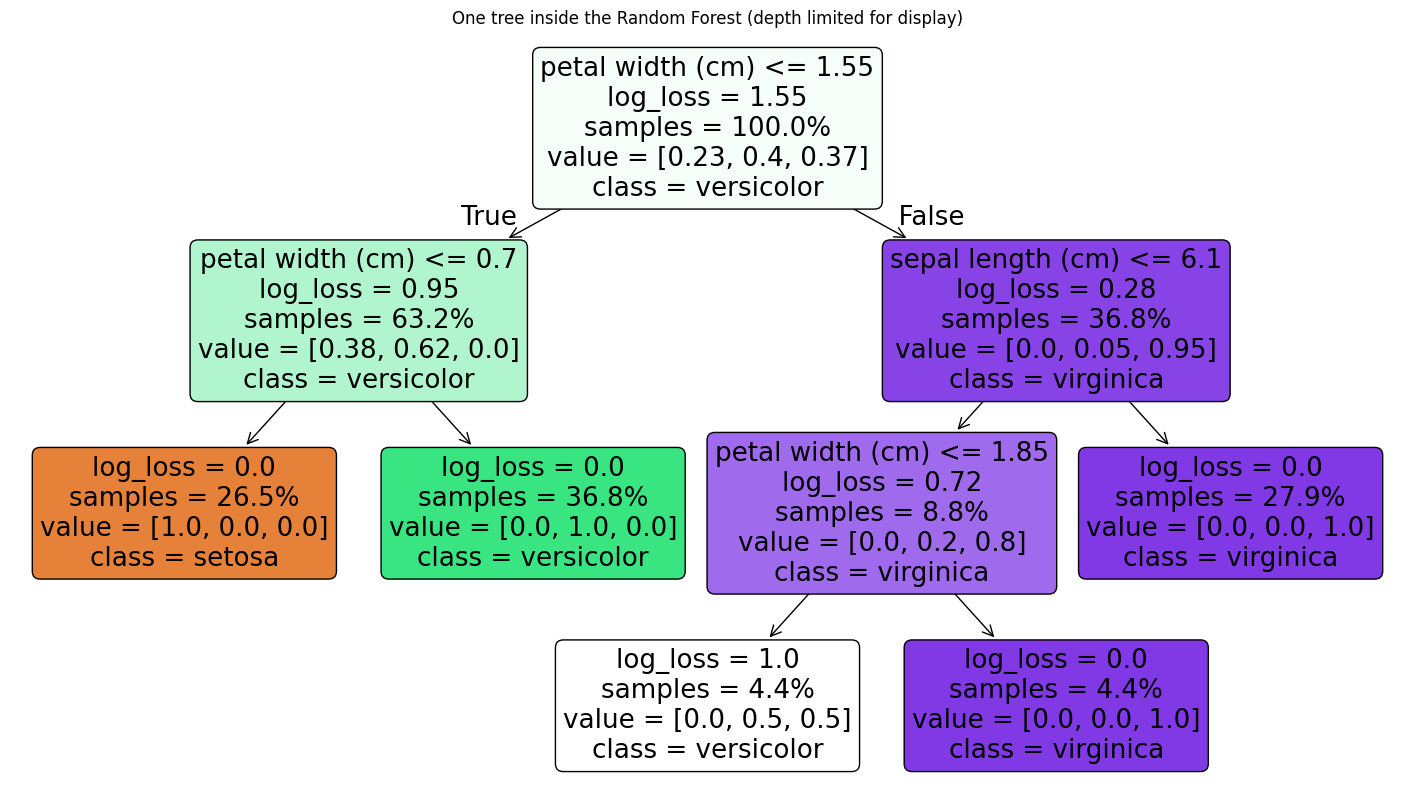

In [56]:
one_tree = rf_baseline.estimators_[0]

plt.figure(figsize=(18, 10))
plot_tree(
    one_tree,
    feature_names=X_train_all.columns,
    class_names=iris["target_names"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    precision=2,
    max_depth=3   # 只畫前幾層，否則通常會非常巨大
)
plt.title("One tree inside the Random Forest (depth limited for display)")
plt.show()


## 小型參數搜尋示範

這裡故意把搜尋範圍控制小一點，避免 notebook 太重。
重點不是把參數網格開到天荒地老，而是理解：

1. 先做一個合理 baseline
2. 再針對少數關鍵參數微調
3. 用交叉驗證決定，而不是用肉眼猜


很多時候 RF 預設或半手調就已經不錯，所以常見策略是：

baseline 先跑  
如果表現已經很好，就不一定硬搜  
如果要正式比模型，再做搜尋  

而且 RF 很常用 RandomizedSearchCV，因為更省時間。

In [57]:
rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 4, 5, None],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", None]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        bootstrap=True,
        oob_score=False,   # GridSearchCV 內就先不開 OOB，避免評估邏輯混雜
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train_all, y_train_all)

print("Best params:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)


Best params: {'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.9618070818070817


In [58]:
rf_best = rf_grid.best_estimator_
rf_best_test_pred = rf_best.predict(X_test_all)

print("Best RF test accuracy:", rf_best.score(X_test_all, y_test_all))
print(classification_report(y_test_all, rf_best_test_pred, target_names=iris["target_names"]))


Best RF test accuracy: 0.9111111111111111
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## 只挑 2 個特徵，畫 Random Forest 的 decision boundary

提醒：這張圖只是為了教學展示。
真正完整的 Random Forest 模型可以同時吃很多特徵，
但 decision boundary 圖通常只能畫 2 維。


In [59]:
X_train_rf_2d, X_test_rf_2d, y_train_rf_2d, y_test_rf_2d = train_test_split(
    iris_data[feature_cols_2d],
    iris_data["target"],
    test_size=0.3,
    random_state=42,
    stratify=iris_data["target"]
)

rf_2d = RandomForestClassifier(
    n_estimators=300,
    criterion="log_loss",
    max_depth=4,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_2d.fit(X_train_rf_2d, y_train_rf_2d)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'log_loss'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

/Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


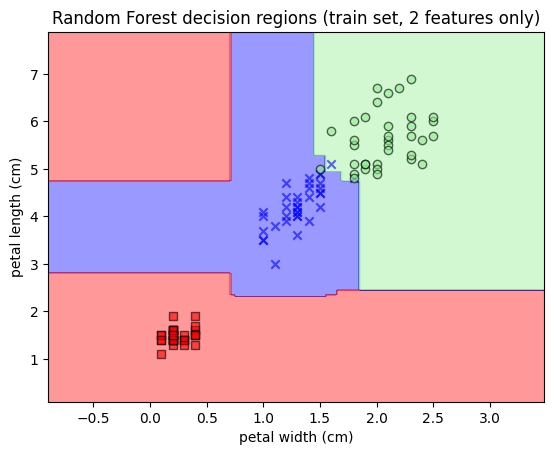

In [60]:
plot_decision_regions(X_train_rf_2d.values, y_train_rf_2d, classifier=rf_2d)
plt.title("Random Forest decision regions (train set, 2 features only)")
plt.xlabel(feature_cols_2d[0])
plt.ylabel(feature_cols_2d[1])
plt.show()


/Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


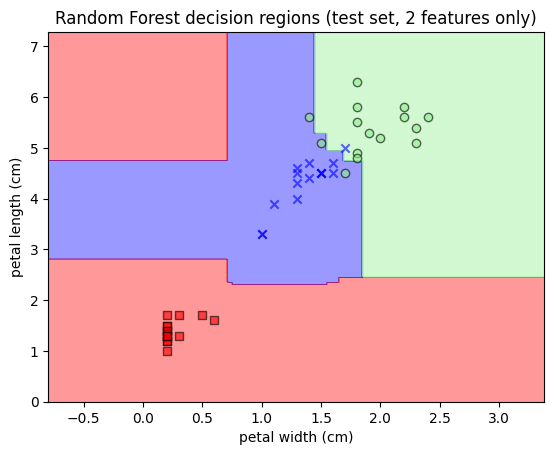

In [61]:
plot_decision_regions(X_test_rf_2d.values, y_test_rf_2d, classifier=rf_2d)
plt.title("Random Forest decision regions (test set, 2 features only)")
plt.xlabel(feature_cols_2d[0])
plt.ylabel(feature_cols_2d[1])
plt.show()


## Decision Tree 與 Random Forest 的一個直白比較

- **Decision Tree**：容易理解、容易畫出來，但也容易 overfit
- **Random Forest**：通常更穩、更實用，但較難完全解釋
- 如果你的目標是：
  - **教學 / 解釋模型規則** → 先看 Decision Tree
  - **追求更穩定的預測表現** → 常先試 Random Forest

一句稍微有點人話的總結：
**Decision Tree 像一位很有主見但可能太武斷的專家；Random Forest 則像找了一群專家投票，比較不容易一個人亂講。**


## ML 評估流程重點整理

### 1. 建立 Baseline（最低標準）

**目的：** 確認模型具備基本預測能力，作為後續比較基準  

- 使用最簡單模型（例如 Decision Tree）
- 使用原始特徵（不做特徵工程）
- 使用預設參數（不調參）

**需記錄：**
- Accuracy
- Precision / Recall / F1-score

> 沒有 baseline，就無法判斷模型是否真的進步


### 2. 模型比較（Model Comparison）

**目的：** 確認分數提升是否來自「模型本身」

- 在相同資料與特徵下比較不同模型  
- 例如：
  - Decision Tree
  - Random Forest

**重點：**
- 控制變因（只換模型）
- 記錄各模型表現

> 這一步是在回答：「哪個模型比較適合這個問題？」


### 3. 特徵工程比較（Feature Engineering）

**目的：** 確認分數提升是否來自「特徵改善」

- 保持模型不變
- 比較：
  - 原始特徵
  - 處理後特徵（補缺值、encoding、衍生特徵）

**重點：**
- 如果分數提升 → 特徵工程有效

> 模型 ≠ 一切，很多時候特徵才是關鍵


### 4. 超參數調整（Hyperparameter Tuning）

**目的：** 進一步優化模型表現

- 使用：
  - GridSearchCV
  - RandomizedSearchCV

**常見參數（Random Forest）：**
- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf

> 測試集不可用來調參（避免 data leakage）


### 5. 整體指標評估

**目的：** 掌握模型整體表現

**常見指標：**

> 不要只看 Accuracy（尤其在資料不平衡時）

| 指標 | 意義 |
|------|------|
| Accuracy | 整體預測正確率 |
| Precision | 預測為正的準確度 |
| Recall | 實際為正被抓到的比例 |
| F1-score | Precision 與 Recall 的平衡 |




### 6. 各類別表現分析

**目的：** 確認模型是否偏向某些類別

- 查看 classification report
- 注意：
  - 哪類 precision 低
  - 哪類 recall 低
  - 是否有類別被忽略

> 整體分數高 ≠ 每一類都做得好


### 7. Confusion Matrix（錯誤分析）

**目的：** 找出模型「錯在哪裡」

- 觀察：
  - 哪些類別互相混淆
  - 哪類最容易被誤判

**用途：**
- 判斷是否需要：
  - 新特徵
  - 換模型
  - 再調參

> Confusion Matrix = 模型錯誤的地圖


### 8. 與 Baseline 最終比較

**目的：** 確認每一步改進的效果

> 重點不是最高分，而是「每一步帶來多少提升」

| 階段 | 模型 | 特徵 | 分數 |
|------|------|------|------|
| Baseline | Decision Tree | 原始特徵 | 0.85 |
| Model | Random Forest | 原始特徵 | 0.91 |
| Feature | Random Forest | 新特徵 | 0.93 |
| Tuned | RF (GridSearch) | 新特徵 | 0.95 |


### 評估思考 Checklist

每次建模請回答：

- 這個模型有比 baseline 好嗎？
- 分數提升來自模型？特徵？還是調參？
- 哪些類別表現不好？
- 模型錯在哪裡？
- 這個錯誤在實務上嚴不嚴重？


### 總結

**`模型評估的核心不是追求高分，而是理解：`**
- 模型為什麼變好
- 哪裡還有問題
- 改進是否有實際價值